#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss
from src.gnn.models import GAT

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt')

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define model

In [4]:
model = GAT(
    in_channels=data.x.shape[1], 
    hidden_channels=32, # Output l1 sẽ là 32*4 = 128
    out_channels=2, 
    heads=4, 
    dropout=0.5
).to(device)

print(model)

GAT(
  (conv1): GATv2Conv(165, 32, heads=4)
  (conv2): GATv2Conv(128, 2, heads=1)
)


#### Focal Loss and Optimizer

In [5]:
weight = compute_class_weights(data, device)

criterion = FocalLoss(weight=weight, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model=model, 
    data=data, 
    optimizer=optimizer, 
    criterion=criterion, 
    save_path='../saved_models/gat_best.pt', 
    num_epochs=200, 
    patience=20
)

Epoch 001: Train Loss=1.2768, Train F1=0.3661, Val F1=0.3895, Gap=-0.0235
Epoch 002: Train Loss=1.0065, Train F1=0.4389, Val F1=0.3876, Gap=0.0513
Epoch 003: Train Loss=0.5711, Train F1=0.5087, Val F1=0.4009, Gap=0.1079
Epoch 004: Train Loss=0.5839, Train F1=0.5516, Val F1=0.4143, Gap=0.1373
Epoch 005: Train Loss=0.4472, Train F1=0.5718, Val F1=0.4199, Gap=0.1519
Epoch 006: Train Loss=0.4598, Train F1=0.5702, Val F1=0.4211, Gap=0.1491
Epoch 007: Train Loss=0.4494, Train F1=0.5408, Val F1=0.4150, Gap=0.1258
Epoch 008: Train Loss=0.3883, Train F1=0.5171, Val F1=0.4109, Gap=0.1063
Epoch 009: Train Loss=0.3639, Train F1=0.5208, Val F1=0.4131, Gap=0.1076
Epoch 010: Train Loss=0.3366, Train F1=0.5459, Val F1=0.4217, Gap=0.1241
Epoch 011: Train Loss=0.3257, Train F1=0.5747, Val F1=0.4345, Gap=0.1402
Epoch 012: Train Loss=0.2910, Train F1=0.5976, Val F1=0.4498, Gap=0.1478
Epoch 013: Train Loss=0.2744, Train F1=0.6019, Val F1=0.4560, Gap=0.1458
Epoch 014: Train Loss=0.2903, Train F1=0.5857, Val

#### Learning curve

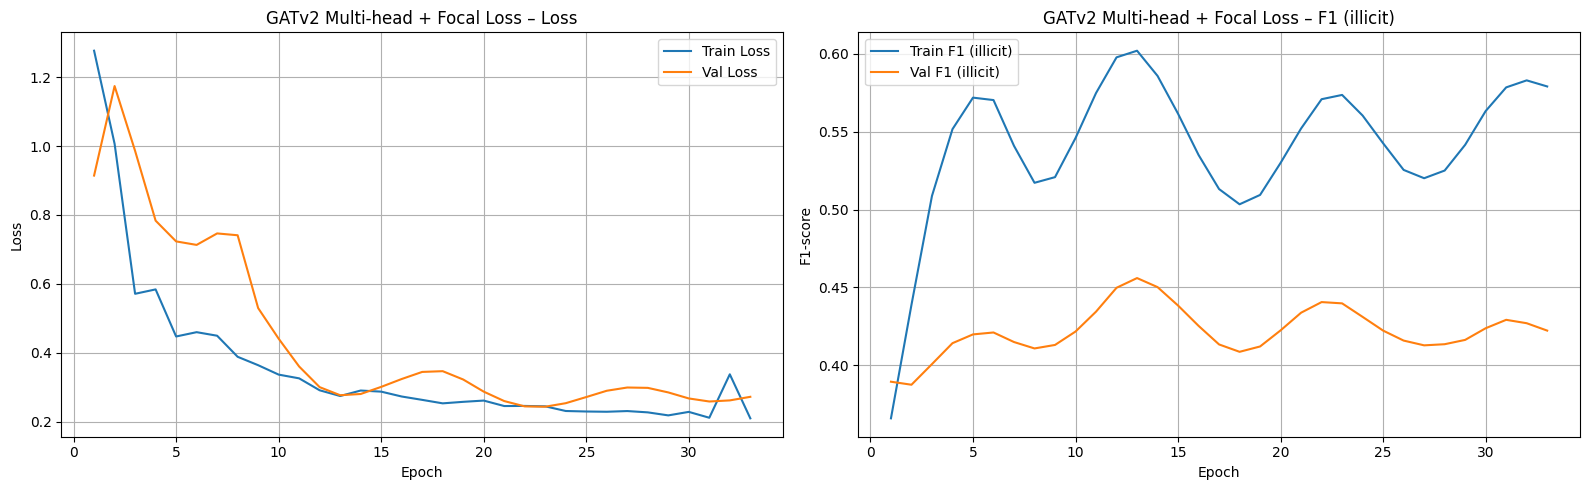

In [7]:
plot_learning_curves(history, model_name="GATv2 Multi-head + Focal Loss")

#### Test evaluation

In [8]:
model.load_state_dict(torch.load('../saved_models/gat_best.pt'))
print_test_evaluation(model, data, criterion, label="GAT Test")

 GAT Test Set Evaluation
  Loss          : 0.3140
  Accuracy      : 0.5961
  Precision(ill): 0.1269
  Recall(ill)   : 0.8873
  F1(illicit)   : 0.2221
  F1(macro)     : 0.4747
  AUC-PR        : 0.5251

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9866    0.5759    0.7272     15587
 Illicit (1)     0.1269    0.8873    0.2221      1083

    accuracy                         0.5961     16670
   macro avg     0.5568    0.7316    0.4747     16670
weighted avg     0.9307    0.5961    0.6944     16670

Confusion Matrix:
[[8976 6611]
 [ 122  961]]
